# The counting experiment

#### The experiment
* Suppose we are doing an experiment that consists in counting how many times we observe an event
* We know that the events we count could be from the signal process we are interested in or from a background process, but we only count the total number

#### The model: Poisson
* We can model the counting experiment with a simple Poisson that depends on the number of expected signal ($s$) and background ($b$) events.
$$ P(n \mid s, b)=\frac{(s+b)^n}{n!} e^{-(s+b)} $$

#### Hypthesis testing: discovery $p$-value
* Our goal is to test the hypothesis that the hypothesis that there is no signal $s=0$ and calculate a $p$-value


## A numerical example:
* We know the expected number of background events $b=0.5$ (with negligible uncertainty)
* We observe $n_{\rm obs} = 5$
* Should we claim that we have discovered signal? What is the $p$-value for the hypothesis $s=0$?

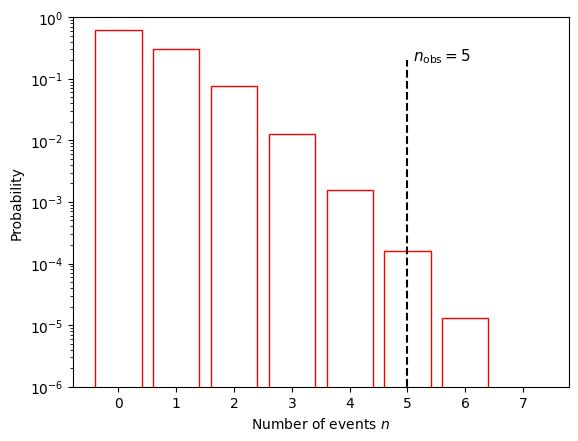

In [ ]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

# define the model
b, s = 0.5, 0
model = stats.poisson(mu = b+s)

# plot the model
k_poisson = np.arange(0, 8)
pmf_poisson = model.pmf(k_poisson) # discrete pdf
plt.bar(k_poisson, pmf_poisson, color='none', edgecolor='red')
plt.xlabel('Number of events $n$')
plt.ylabel('Probability')

plt.vlines(5, 0, 0.2, color='k', linestyle='--')
plt.text(5.1, 0.2, r'$n_{\rm obs}=5$', fontsize=11)
plt.ylim(1e-6 , 1)
plt.yscale('log')
plt.show()
#@title { vertical-output: true}


$p \text{-value }  =P\left(n \geq 5 ; b=0.5, s=0\right)$

In [ ]:
# calculate probability to observe 5 events or more
pval = model.sf(4)
print(f'The p-value is {pval:.4%}')

The p-value is 0.0172%


**N.B.: the p-value is not the probability of the hypothesis that $s=0$!**

The p-value in this case is the probability under the assumption of $s=0$ to observe 5 events or more

### From $p$-value to significance (Z-score)

* Often the $p$-value gets converted to another number called significance or Z-score
* Defined as the number of standard deviations that a Gaussian variable would fluctuate in one direction to give the same $p$-value.

$$
\begin{aligned}
&p=\int_Z^{\infty} \frac{1}{\sqrt{2 \pi}} e^{-x^2 / 2} d x=1-\Phi(Z)\\
&Z=\Phi^{-1}(1-p)
\end{aligned}
$$

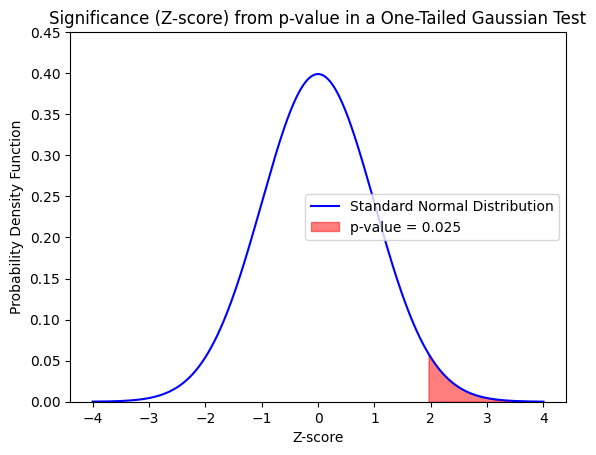

In [ ]:
from scipy.stats import norm

# Define a p-value
p_value = 0.025  # Example p-value

# Calculate Z from the p-value using the inverse survival function
Z_score = norm.ppf(1 - p_value)

# Plot the standard normal distribution (mean=0, std=1)
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x), color='blue', label='Standard Normal Distribution')

# Shade the tail area corresponding to the p-value
x_tail = np.linspace(Z_score, 4, 100)
plt.fill_between(x_tail, 0, norm.pdf(x_tail), color='red', alpha=0.5, label=f'p-value = {p_value:.3f}')

# Add labels and title
plt.title('Significance (Z-score) from p-value in a One-Tailed Gaussian Test')
plt.xlabel('Z-score')
plt.ylabel('Probability Density Function')
plt.legend()
plt.ylim(0, 0.45)
plt.show()
#@title { vertical-output: true}

In [ ]:
# Significance (Z-score) for a given p-value
pval = 0.05
Z = norm.ppf(1-pval) #Quantile
print(f'The significance for a p-value of {pval} is {Z}')

The significance for a p-value of 0.05 is 1.6448536269514722


In [ ]:
# p-value for a given significance of Z sigma:
Z = 3
pval = norm.sf(Z)
print(f'The p-value for {Z} sigmas is {pval:%}')

The p-value for 3 sigmas is 0.134990%


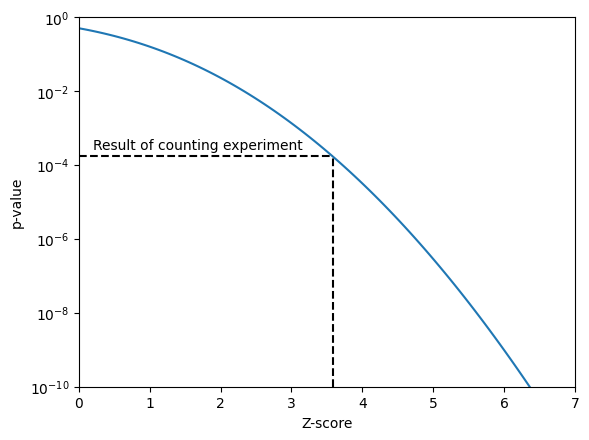

In [ ]:
# plot significance versus p-value
Z_values = np.linspace(0, 7, 100)
p_values = norm.sf(Z_values) # sf 1-cdf

plt.plot(Z_values, p_values, label='Z-score vs. p-value')
plt.ylabel('p-value')
plt.xlabel('Z-score')
plt.yscale('log')
plt.xlim(0,7)
plt.ylim(1e-10, 1)

# result of counting exp above
pval = model.sf(4)
zval = norm.ppf(1-pval)
plt.vlines(zval, 1e-10, pval, color='k', linestyle='--')
plt.hlines(pval, 0, zval, color='k', linestyle='--')
plt.text(0.2, pval*1.5, 'Result of counting experiment', color='k')

plt.show()
#@title { vertical-output: true}